In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6,6)

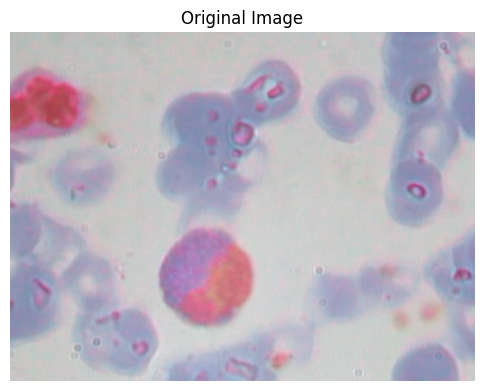

In [10]:
# Read image
img = cv2.imread(r"C:\Users\marc\Downloads\dataset-master\dataset-master\JPEGImages\BloodImage_00044.jpg")  # Put any image in your folder

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

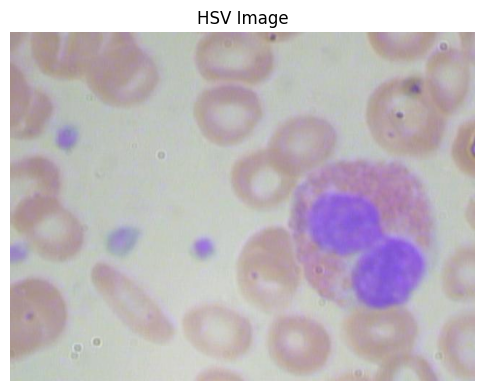

Image shape: (480, 640, 3)


In [23]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lower_purple = np.array([120, 50, 50])
upper_purple = np.array([160, 255, 255])

mask_wbc = cv2.inRange(hsv, lower_purple, upper_purple)
# Matplotlib بيقرأ RGB، فـ نحول من HSV → RGB علشان العرض
hsv_display = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

plt.imshow(hsv_display)
plt.title("HSV Image")
plt.axis("off")
plt.show()

print("Image shape:", hsv.shape)

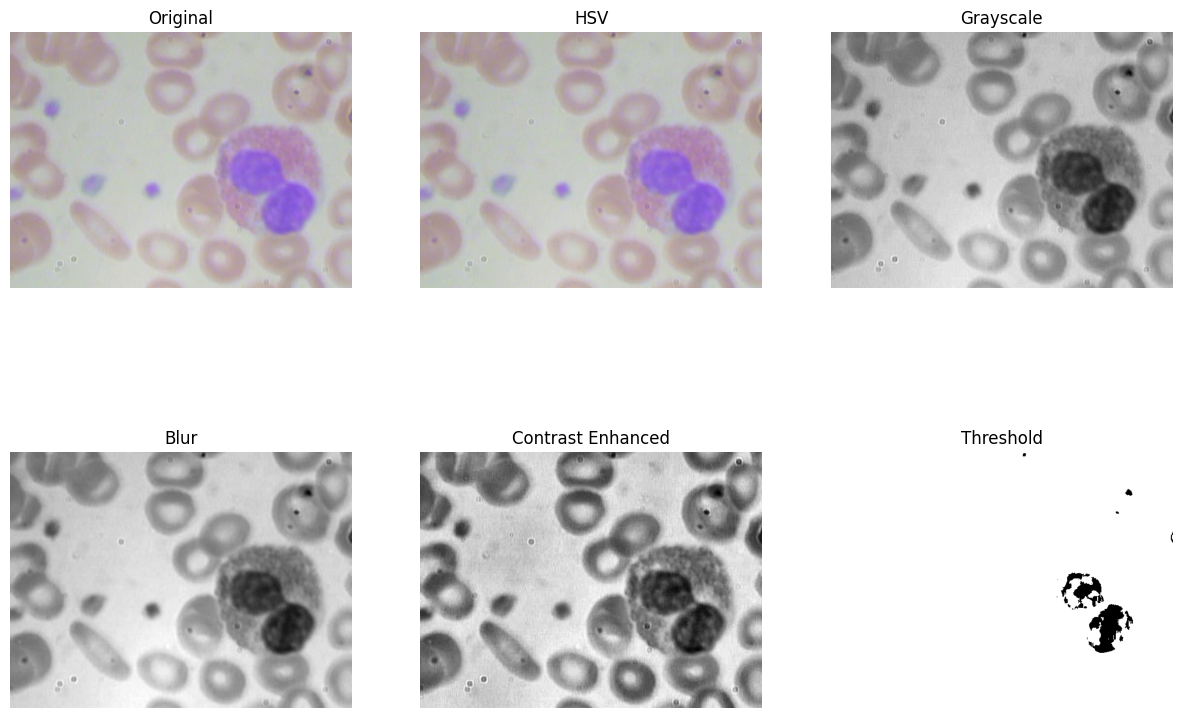

Image shape: (480, 640)


In [24]:
import cv2
import matplotlib.pyplot as plt

# Original image (BGR)
original = img

# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Convert to HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
hsv_display = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)  # علشان العرض في matplotlib

# 1) Blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

# 2) Contrast Enhancement (CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
contrast = clahe.apply(gray)

# 3) Thresholding
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Display images
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(hsv_display)
plt.title("HSV")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(blur, cmap='gray')
plt.title("Blur")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(contrast, cmap='gray')
plt.title("Contrast Enhanced")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(thresh, cmap='gray')
plt.title("Threshold")
plt.axis("off")

plt.show()

print("Image shape:", gray.shape)


### Morphological Operations

In [25]:
import numpy as np

# Morphological kernel
kernel = np.ones((3,3), np.uint8)

# 1) Opening -> remove noise
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# 2) Closing -> fill holes
closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

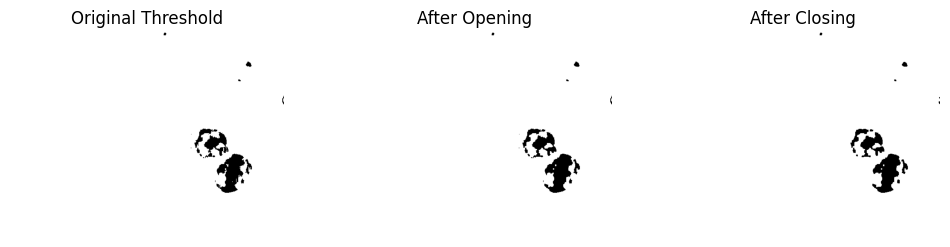

In [26]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(thresh, cmap='gray')
plt.title("Original Threshold")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(opening, cmap='gray')
plt.title("After Opening")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(closing, cmap='gray')
plt.title("After Closing")
plt.axis("off")

plt.show()

In [32]:
import cv2
import os
import numpy as np

# ----------------------------
# Folders
# ----------------------------
folder_path = r"C:\Users\marc\Downloads\dataset-master\dataset-master\JPEGImages"
output_folder = "preprocessed_output"

os.makedirs(output_folder, exist_ok=True)

# Get images
images = [f for f in os.listdir(folder_path)
          if f.endswith(('.png', '.jpg', '.jpeg'))]

# kernel for morphology
kernel = np.ones((3, 3), np.uint8)

# ----------------------------
# Loop over images
# ----------------------------
for img_name in images:

    img_path = os.path.join(folder_path, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    # 1. Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Gaussian Blur (noise removal)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # 3. CLAHE (contrast enhancement)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    contrast = clahe.apply(blur)

    # 4. OTSU Threshold (IMPORTANT FIX)
    _, thresh = cv2.threshold(
        contrast, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # 5. Morphological Operations (stronger pipeline)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=2)
    eroded = cv2.erode(closing, kernel, iterations=1)

    # ----------------------------
    # Save result
    # ----------------------------
    save_path = os.path.join(output_folder, img_name)
    cv2.imwrite(save_path, eroded)

print("Preprocessing Done ✔")

Preprocessing Done ✔


detection marc


In [4]:
import cv2
import os
import numpy as np

# 1. Folders Setup
folder_path = r"C:\Users\marc\Downloads\dataset-master\dataset-master\JPEGImages"
output_folder = "detection_results"
os.makedirs(output_folder, exist_ok=True)

images = [f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

print(f"Starting Detection for {len(images)} images...")

for img_name in images:
    img_path = os.path.join(folder_path, img_name)
    img = cv2.imread(img_path)
    if img is None: continue
    
    # نسخة للرسم عليها
    output_visual = img.copy()
    
    # --- STEP 1: Preprocessing ---
    # تحويل لـ Gray وتقليل الضوضاء
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.medianBlur(gray, 5) # الـ median أفضل في الحفاظ على الحواف
    
    # تحسين التباين (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    contrast = clahe.apply(blurred)

    # --- STEP 2: Thresholding ---
    # بنحول الصورة لـ Binary (الخلايا بيضاء والخلفية سوداء)
    _, thresh = cv2.threshold(contrast, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # تنظيف الـ Mask
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # --- STEP 3: Separation (Watershed) ---
    # تحديد المنطقة اللي أكيد خلفية
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # تحديد المنطقة اللي أكيد "قلب" الخلية (Distance Transform)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.2 * dist_transform.max(), 255, 0) # الـ 0.2 دي بتتحكم في الفصل
    
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    # عمل Markers لكل خلية
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    # تطبيق الـ Watershed
    markers = cv2.watershed(img, markers)
    
    # --- STEP 4: Extraction & Drawing ---
    # استخراج الـ Contours النهائية بعد الفصل
    labels = np.unique(markers)
    cell_count = 0
    
    for label in labels:
        if label <= 1: # تجاهل الخلفية والحدود
            continue
            
        # عمل Mask لكل خلية لوحدها
        target_cell_mask = np.uint8(markers == label)
        cnts, _ = cv2.findContours(target_cell_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if cnts:
            cnt = cnts[0]
            area = cv2.contourArea(cnt)
            if area < 100: continue # تجاهل أي noise
            
            cell_count += 1
            # رسم حدود الخلية باللون الأزرق (للدلالة على الـ Detection فقط)
            cv2.drawContours(output_visual, [cnt], -1, (255, 0, 0), 2)
            
            # تحديد المركز لوضع الرقم
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                cv2.putText(output_visual, str(cell_count), (cX-10, cY), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

    # كتابة العدد الإجمالي
    cv2.putText(output_visual, f"Total Cells Detected: {cell_count}", (20, 40), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

    # حفظ النتيجة
    cv2.imwrite(os.path.join(output_folder, img_name), output_visual)

print(f"Detection phase done! Results in '{output_folder}'")

Starting Detection for 366 images...
Detection phase done! Results in 'detection_results'
